# Context-dependent perturbation responses

Shared GRN across three contexts (A, B, C) but different latent-program activity levels.
Programs that are inactive in a context are gated out via a sigmoid, so KO effects on
their genes don't propagate.  The context design has:

- two programs **shared by all three** contexts
- three programs **pair-shared** (one pair each of A+B, B+C, A+C)
- three programs **unique** to a single context
- remaining programs inactive in every context

In [1]:
import pickle
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path

from PerturbSeqSimulator import PerturbSeqSimulator

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load artifacts written by notebook 08

Notebook 08 builds and saves the GRN, the per-context activity design,
and the per-context control AnnDatas. We just load them here — no
recomputation. Required files (all in `./DATA/`):

- `grn.pkl`
- `context_design.pkl` — `{activities, context_active_idx, HIGH, LOW, program_names}`
- `control_data_A.h5ad`, `control_data_B.h5ad`, `control_data_C.h5ad`

In [ ]:
DATA_DIR = Path('./DATA')

with open(DATA_DIR / 'grn.pkl', 'rb') as f:
    grn = pickle.load(f)

with open(DATA_DIR / 'context_design.pkl', 'rb') as f:
    design = pickle.load(f)

activities         = design['activities']
context_active_idx = design['context_active_idx']
program_names      = design['program_names']
n_programs         = len(program_names)

# Gate parameters solved in notebook 08 (preset: target gate ratio ~4)
sigmoid_threshold = design['sigmoid_threshold']
sigmoid_scale     = design['sigmoid_scale']
print(f"Gate: sigmoid_threshold={sigmoid_threshold:.4f}, sigmoid_scale={sigmoid_scale:.4f}")
print(f"      target gate(HIGH={design['HIGH']})={design['gate_high']}, "
      f"gate(LOW={design['LOW']})={design['gate_low']}  -> ratio "
      f"{design['gate_high']/design['gate_low']:.2f}")

# Per-context control AnnDatas written by notebook 08
context_controls = {
    name: sc.read_h5ad(DATA_DIR / f'control_data_{name}.h5ad')
    for name in activities
}

print(f"\nPrograms ({n_programs}):")
for i, p in enumerate(program_names):
    print(f"  [{i:2d}] {p}")
print(f"\nContexts loaded: {list(context_controls)}")
for name, ad_ in context_controls.items():
    print(f"  {name}: {ad_.shape}, layers={list(ad_.layers)}")

## Inspect the loaded design

Just a sanity print of the per-context program activity (already
designed and persisted in notebook 08). The full heatmap lives in 08;
here we only confirm what was loaded.

In [ ]:
# Activity design was built and saved by notebook 08; just inspect it here.
# Programs with activity >= HIGH are "active" in that context.
HIGH = design['HIGH']
design_df = pd.DataFrame(
    {name: np.where(activities[name] >= HIGH, 'ON', '.') for name in activities},
    index=program_names,
)
print('Per-context program activity (loaded from notebook 08):')
print(design_df.to_string())

## Simulate perturbations per context

Same GRN and the same set of perturbed genes across all three contexts,
but each context uses **its own control cells** and **its own
`program_activity` vector**. Both the baseline expression and the
sigmoid gate on perturbation propagation differ by context, so the
simulated KO responses differ by context too.

Outputs per context written to `./DATA/`:
- `perturbseq_<ctx>.h5ad` — perturbed cells + control
- `gt_<ctx>.pkl`           — ground-truth log2 FC matrix

In [ ]:
DATA_DIR.mkdir(exist_ok=True)

# Perturb every real + synthetic gene that belongs to at least one program.
# (sim.perturbable_genes is the union of genes with any non-zero V column.)
N_CELLS_PER_PERT = 200

# Same KO set across contexts — built from the first simulator
perturbation_set = None

context_adatas = {}
context_gt = {}

for name, activity_vec in activities.items():
    print(f"\n=== context_{name} ===")
    sim = PerturbSeqSimulator(
        grn=grn,
        control_adata=context_controls[name],   # per-context baseline
        counts_layer='raw_counts',
        program_activity=activity_vec,           # per-context gate input
        sigmoid_threshold=sigmoid_threshold,     # gate solved in notebook 08
        sigmoid_scale=sigmoid_scale,
        verbose=True,
    )

    if perturbation_set is None:
        perturbation_set = list(sim.perturbable_genes)
        print(f"(will perturb the same {len(perturbation_set)} program-member "
              f"genes in every context)")

    adata_ctx = sim.simulate_all_perturbations(
        n_cells_per_perturbation=N_CELLS_PER_PERT,
        genes_to_perturb=perturbation_set,
        include_control=True,
    )
    adata_ctx.obs['context'] = f'context_{name}'
    adata_ctx.write(DATA_DIR / f'perturbseq_{name}.h5ad')
    context_adatas[name] = adata_ctx

    gt = sim.get_ground_truth_log2fc(genes_to_perturb=perturbation_set)
    gt.to_pickle(DATA_DIR / f'gt_{name}.pkl')
    context_gt[name] = gt

    print(f"  adata: {adata_ctx.shape}, gt: {gt.shape}")

## Compare GT and empirical logFCs across contexts

Three panels per estimator, same column order (clustered from the GRN
membership matrix), shared row/column program-membership annotations.
Rows cluster within each panel.

In [5]:
# Non-filler gene mask + membership matrix (shared columns / annotations)
non_filler_mask = np.array([not g.startswith('GENE_') for g in grn.all_genes])
non_filler_genes = [g for g, nf in zip(grn.all_genes, non_filler_mask) if nf]

w_non_filler = grn.W[non_filler_mask, :]
membership = (w_non_filler != 0).astype(int).T
membership_df = pd.DataFrame(
    membership, index=grn.program_names, columns=non_filler_genes
)

# Cluster columns once to get the shared gene order
g_mem = sns.clustermap(
    membership_df, method='average',
    cmap='Greys', cbar_pos=None,
    figsize=(0.1, 0.1),
)
clustered_gene_order = list(g_mem.data2d.columns)
plt.close(g_mem.fig)

program_colors = dict(zip(
    grn.program_names,
    sns.color_palette('tab10', len(grn.program_names))
))

def build_program_colors(gene_list):
    df = pd.DataFrame(index=list(gene_list))
    for prog in membership_df.index:
        df[prog] = [
            program_colors[prog]
            if (g in membership_df.columns and membership_df.loc[prog, g] == 1)
            else 'white'
            for g in df.index
        ]
    return df

print(f"Shared column order: {len(clustered_gene_order)} non-filler genes")

Shared column order: 1695 non-filler genes


In [6]:
# Empirical logFC per context: mean(log2(X+1)) difference
def empirical_log2fc(adata):
    raw = adata.layers['raw_counts'] if 'raw_counts' in adata.layers else adata.X
    if sp.issparse(raw):
        raw = raw.toarray()
    raw = np.asarray(raw, dtype=np.float64)
    groups = adata.obs['perturbation'].values
    ctrl = groups == 'control'
    log2_ctrl = np.log2(raw[ctrl] + 1).mean(axis=0)
    perts = [p for p in np.unique(groups) if p != 'control']
    rows = {p: np.log2(raw[groups == p] + 1).mean(axis=0) - log2_ctrl for p in perts}
    return pd.DataFrame(rows, index=adata.var_names).T

context_emp = {name: empirical_log2fc(ad) for name, ad in context_adatas.items()}
for name, emp in context_emp.items():
    print(f"{name}: empirical FC matrix {emp.shape}")

A: empirical FC matrix (1695, 5000)
B: empirical FC matrix (1695, 5000)
C: empirical FC matrix (1695, 5000)


Shared color scale +/-4.99


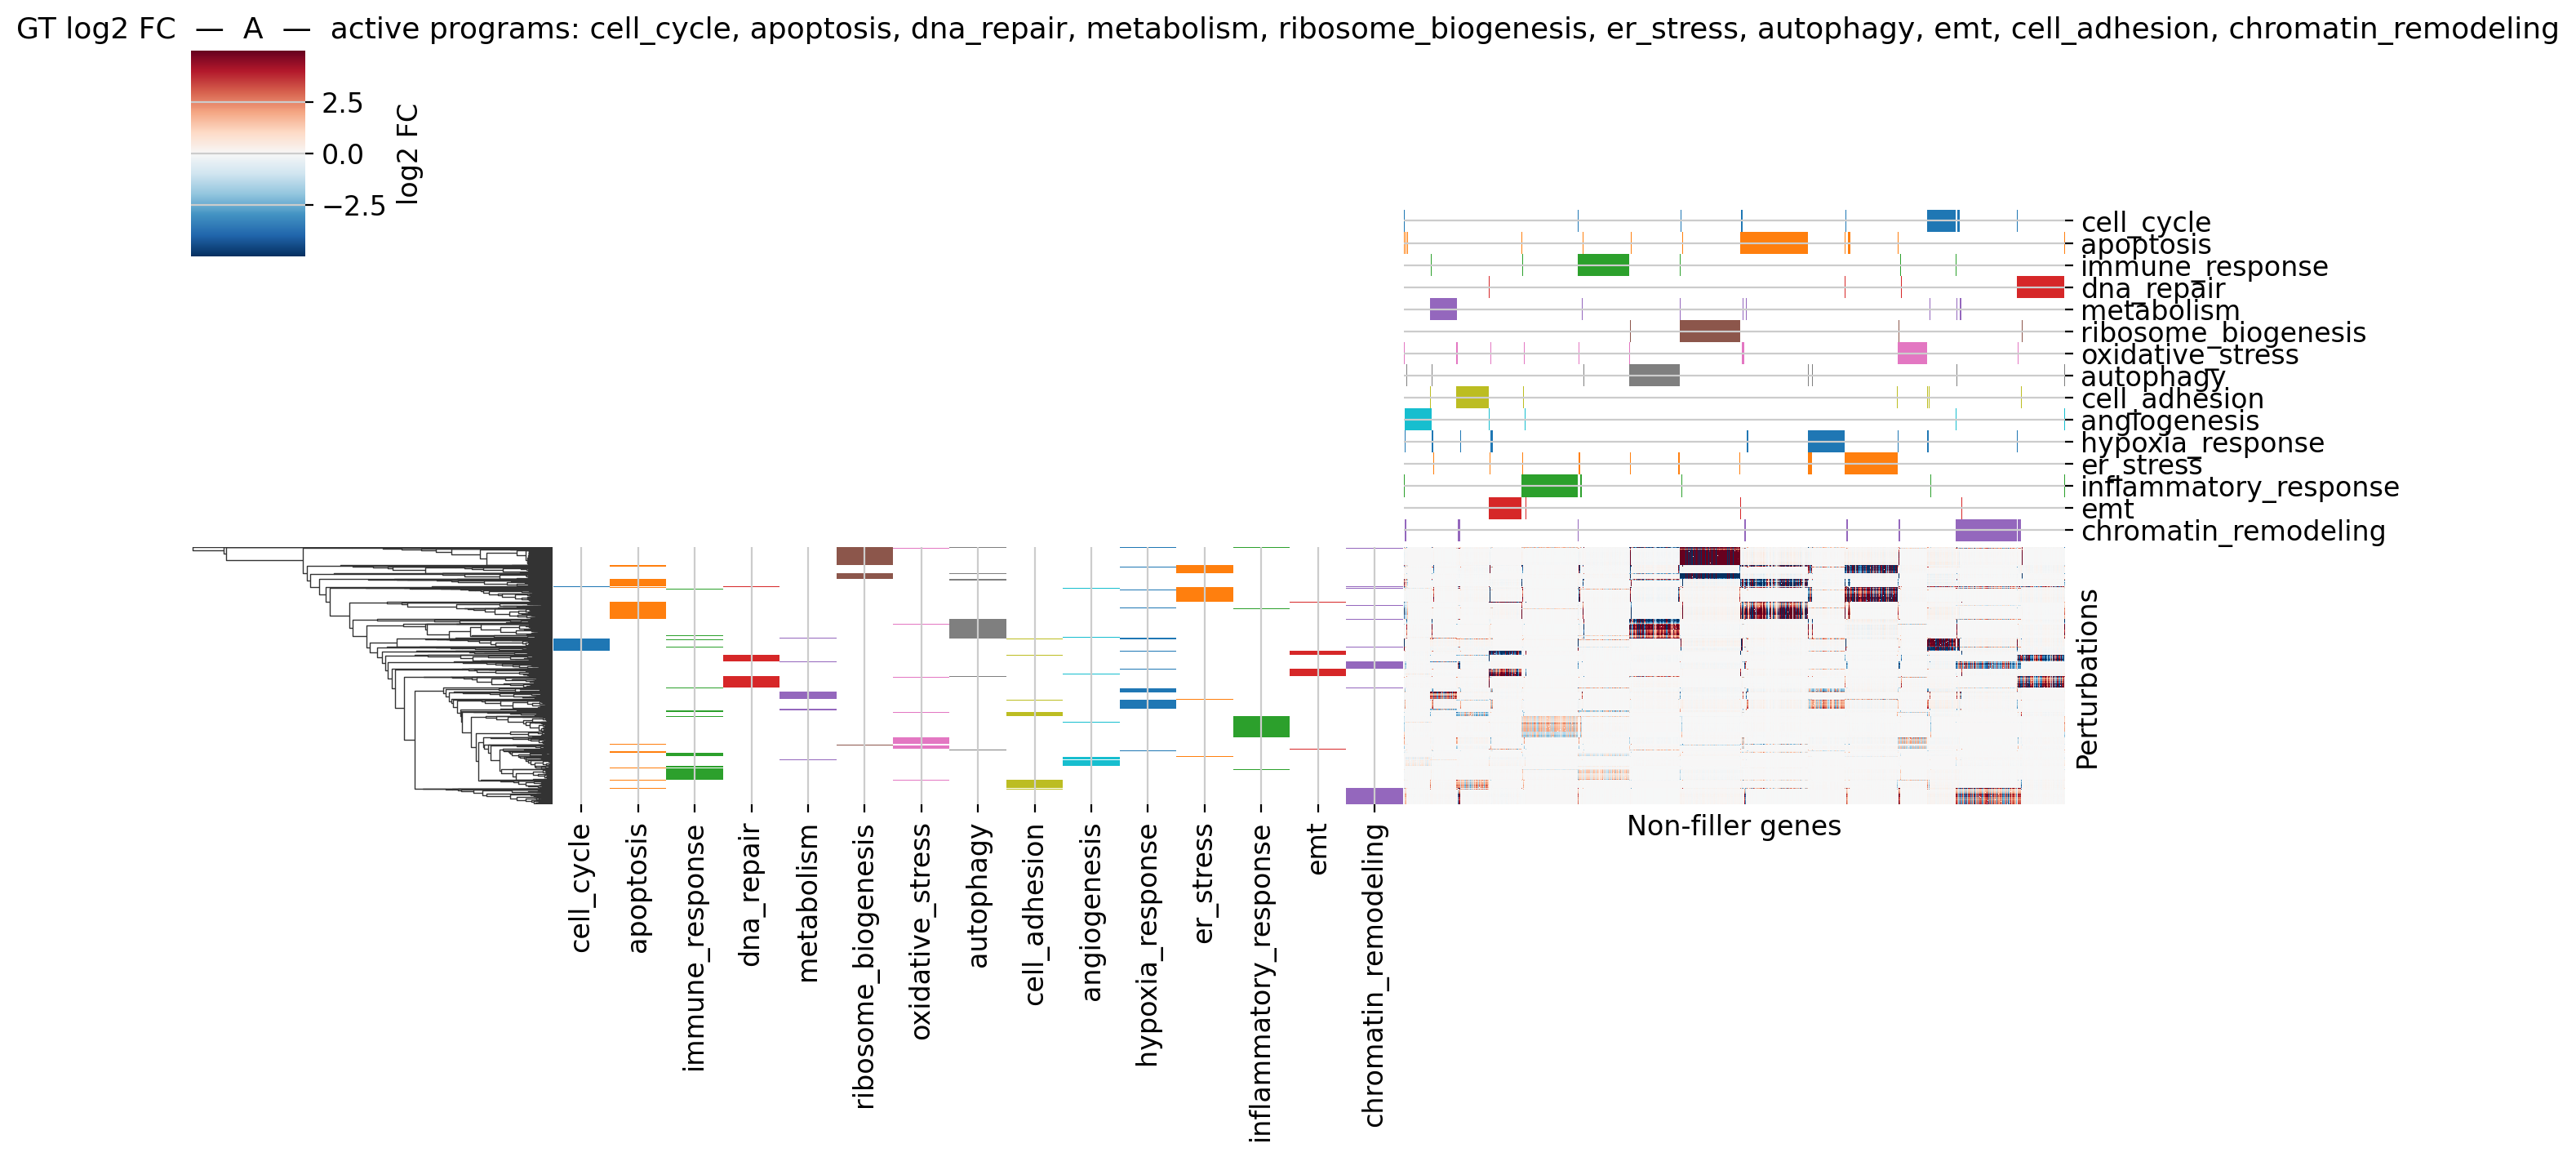

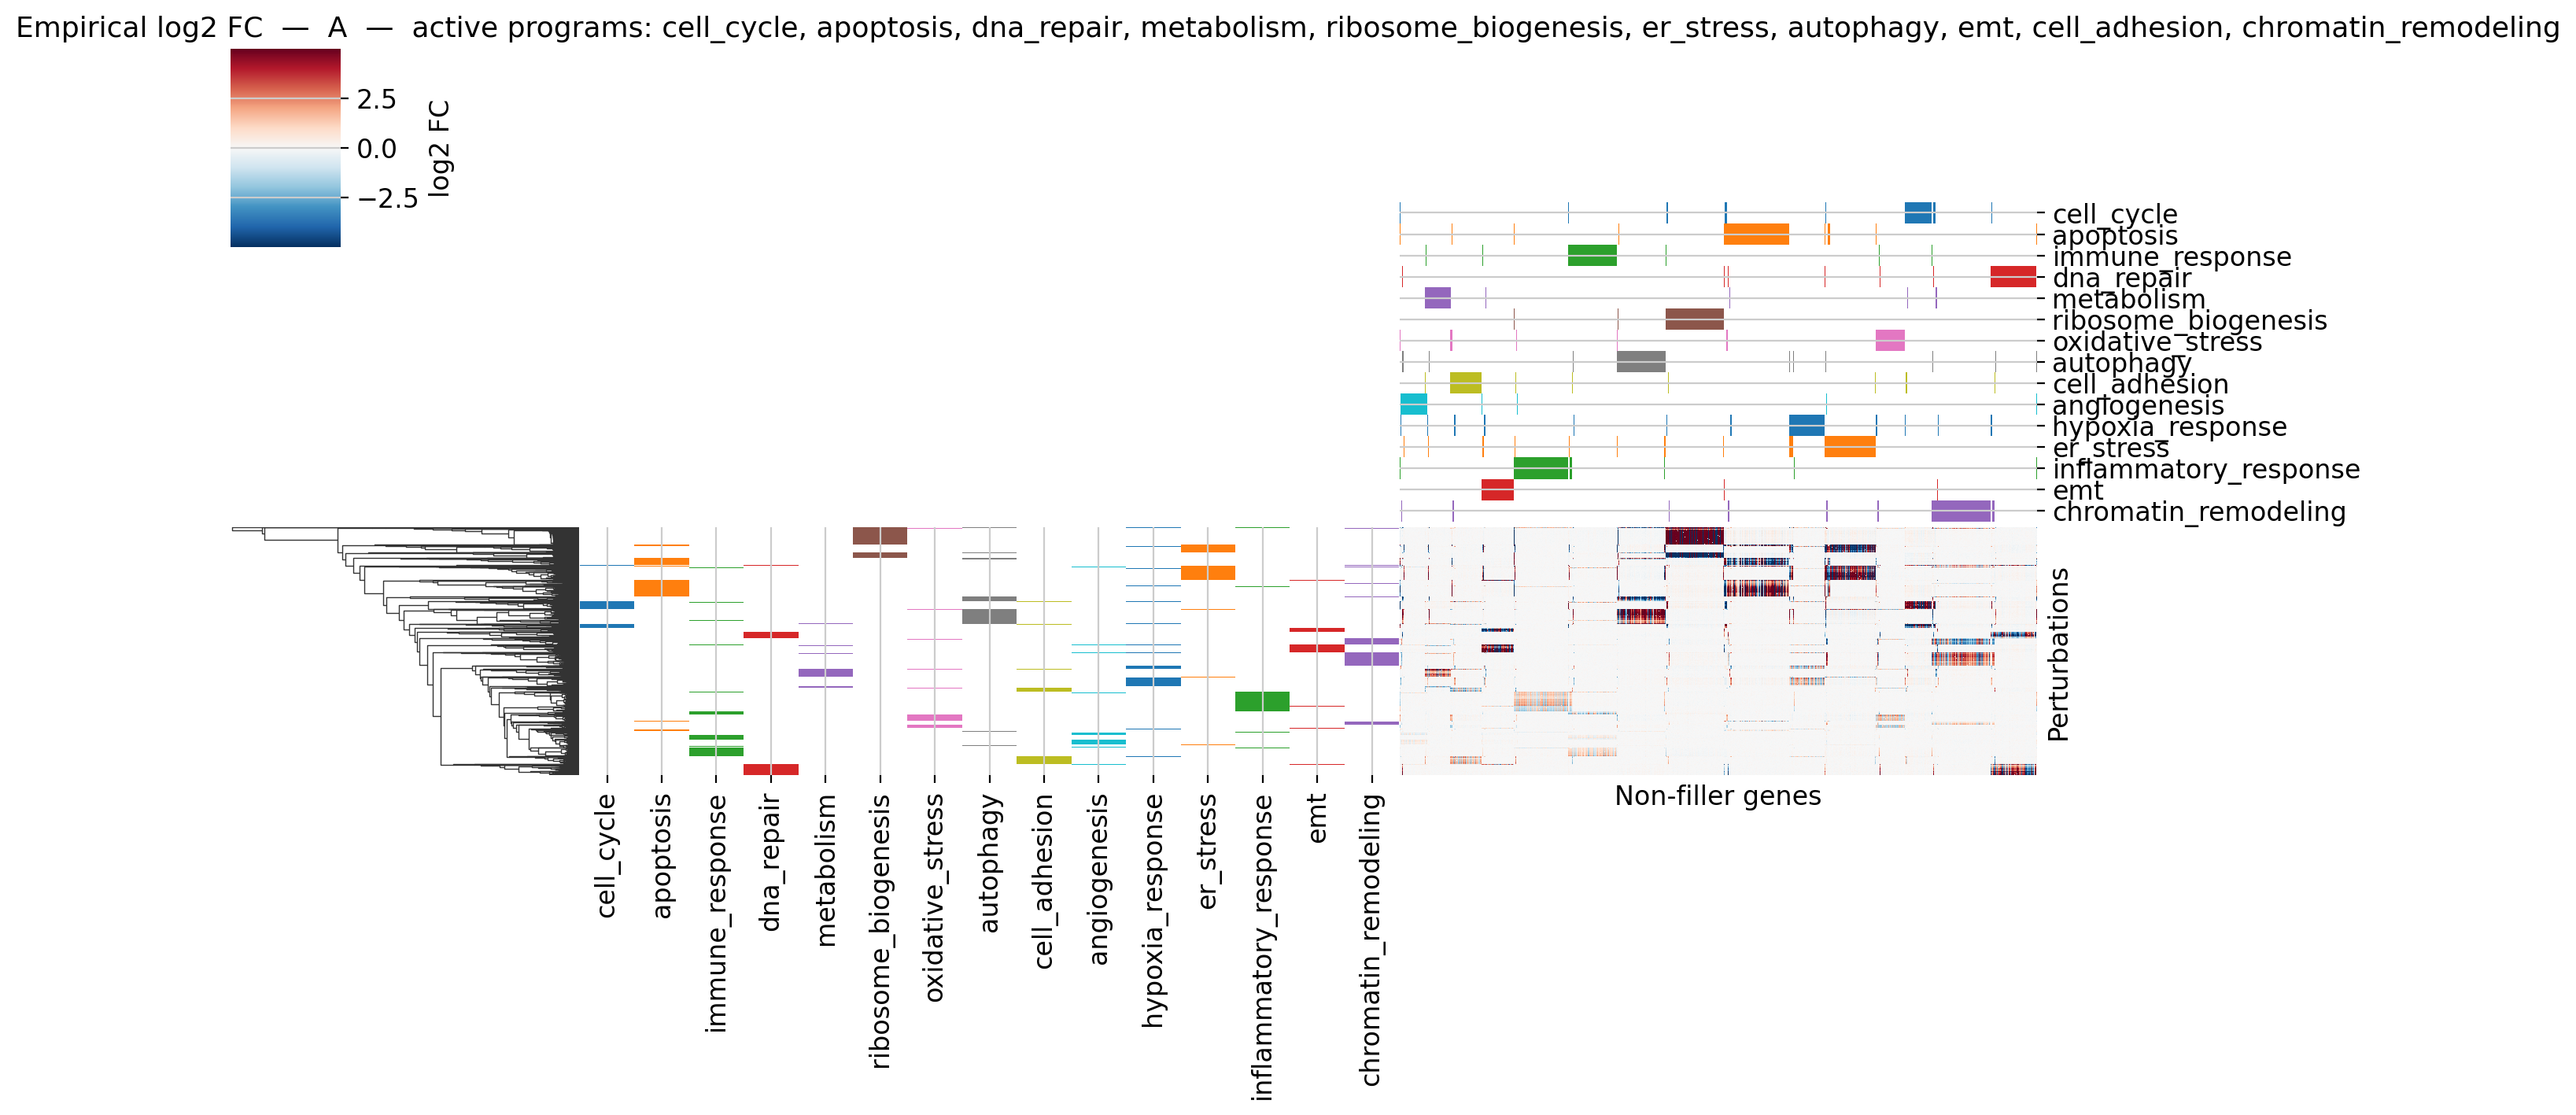

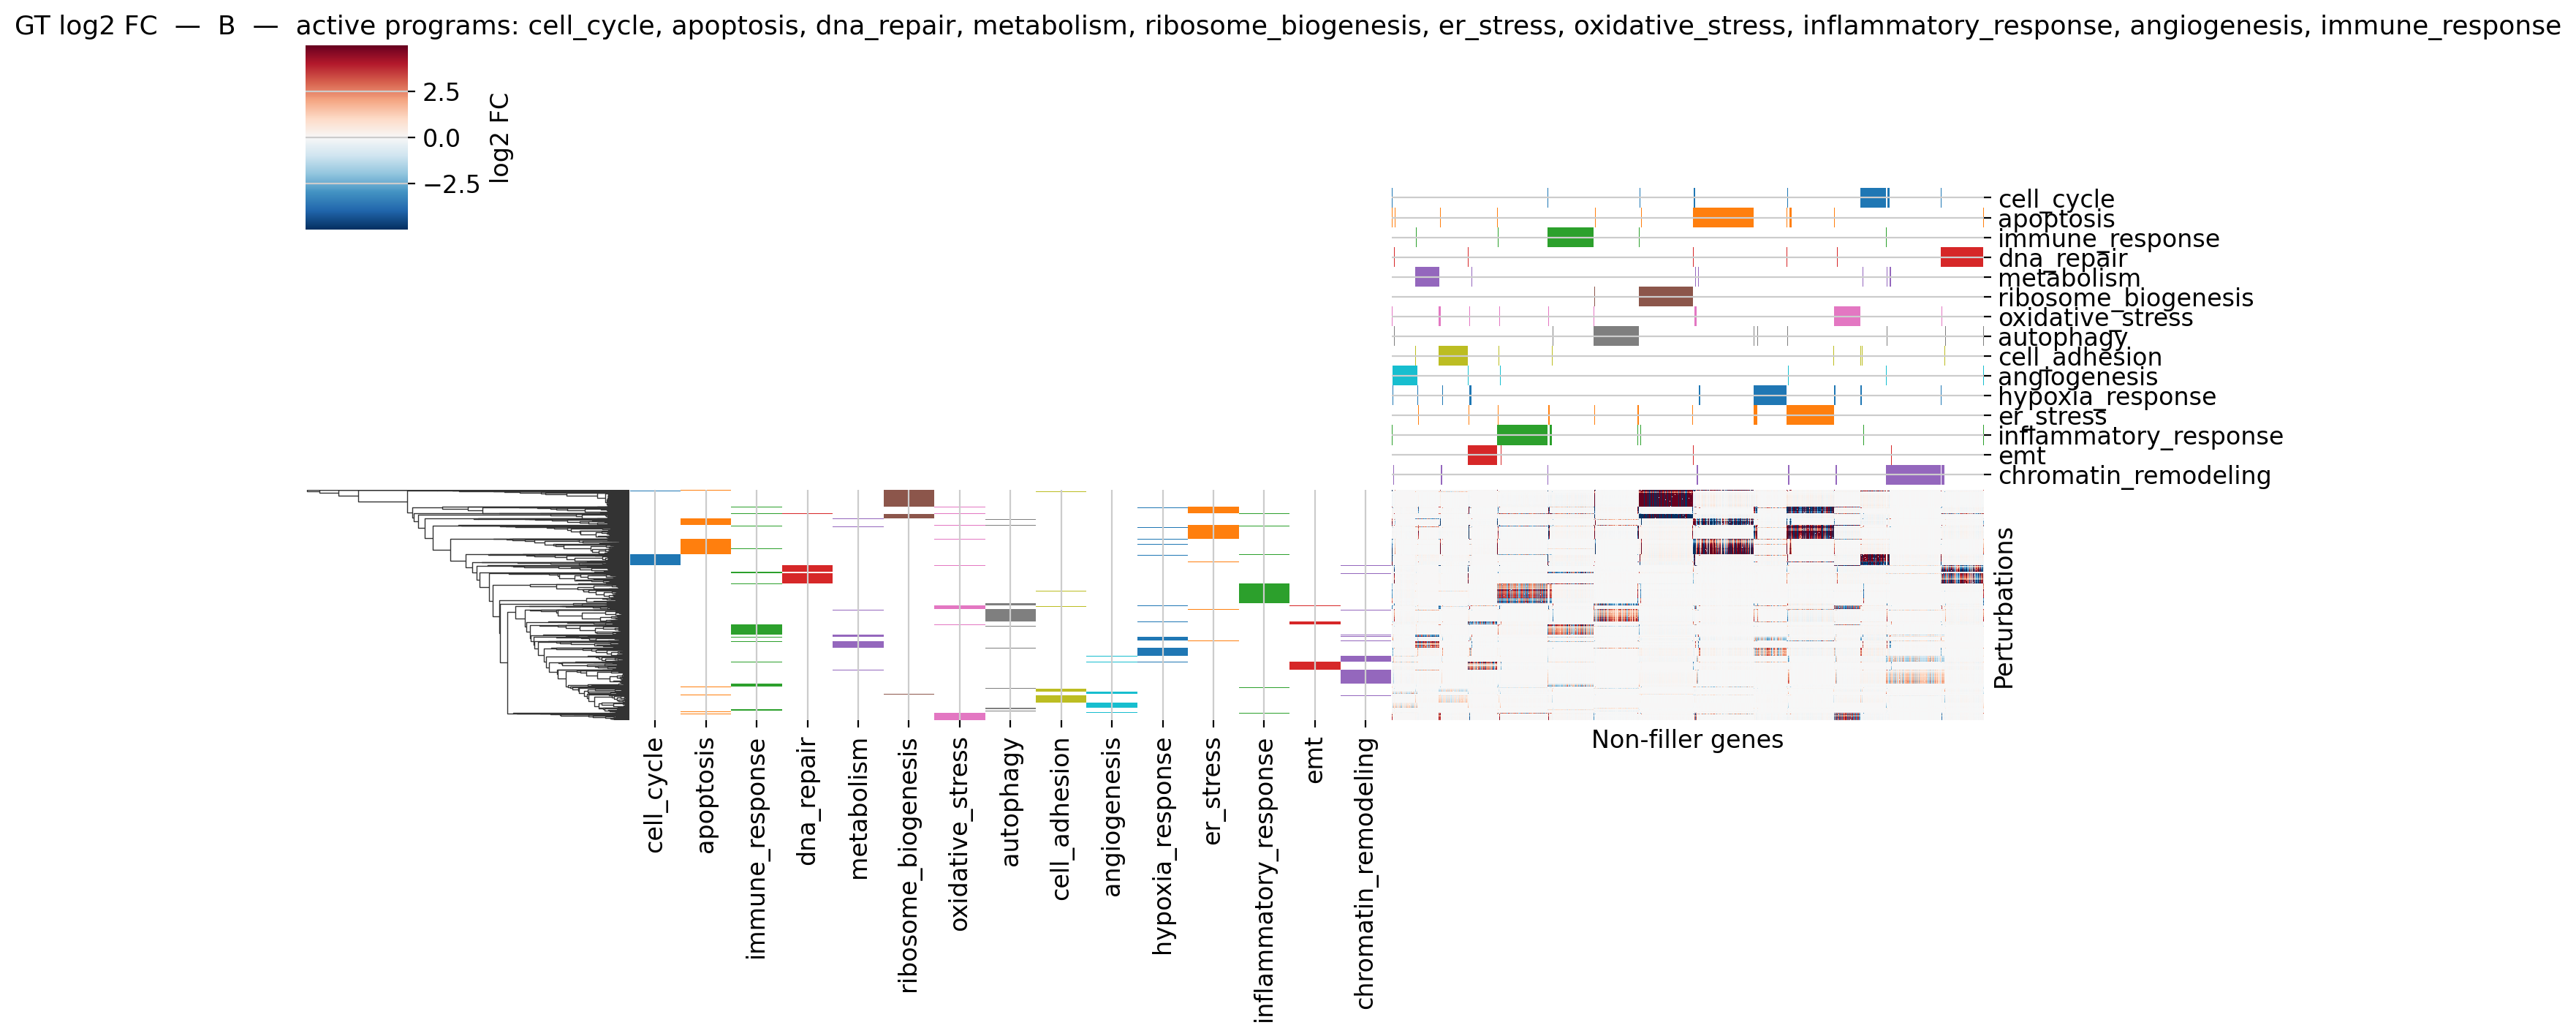

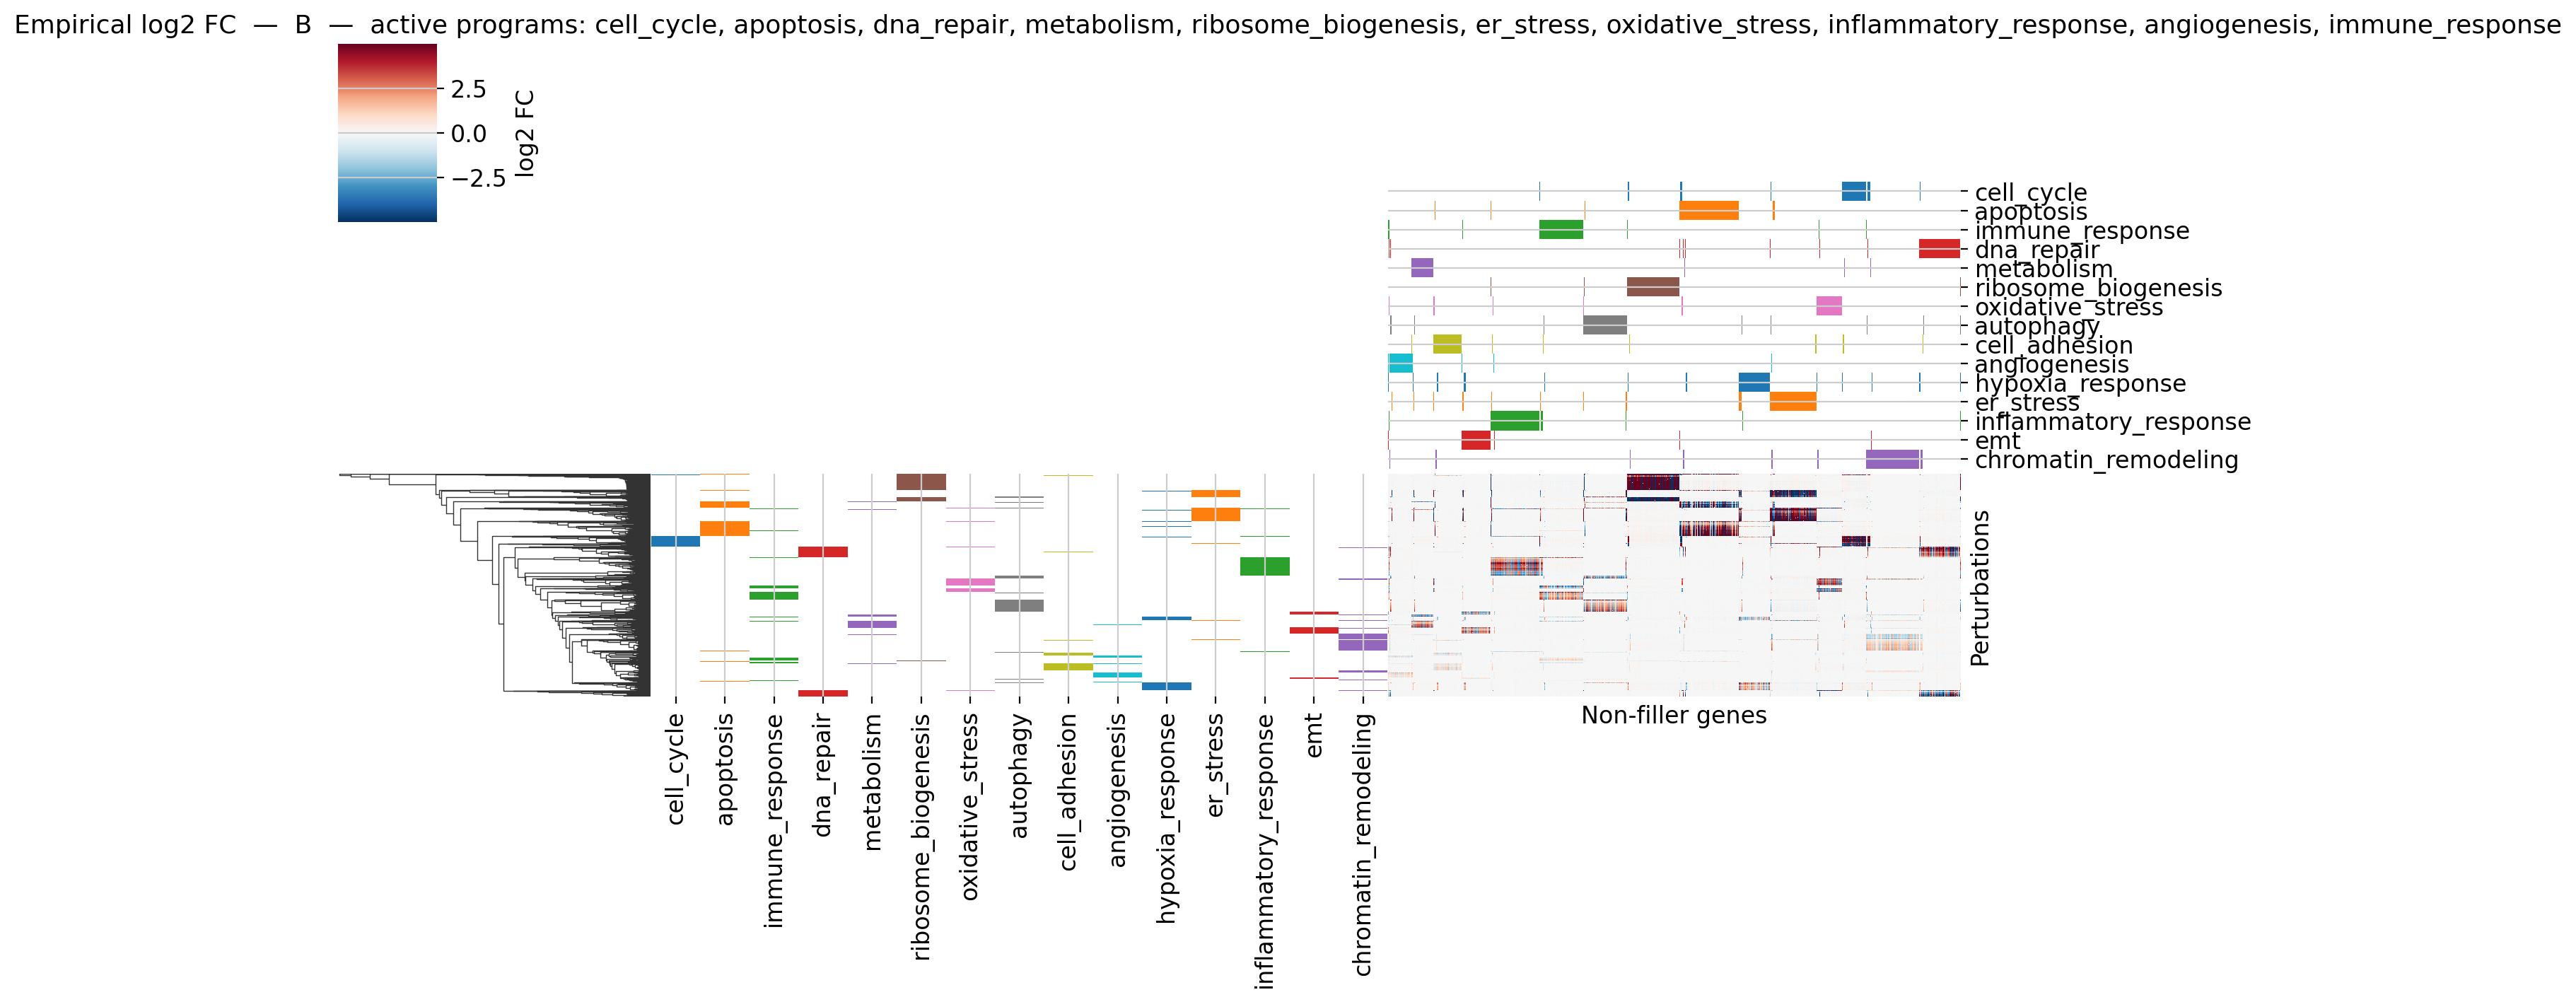

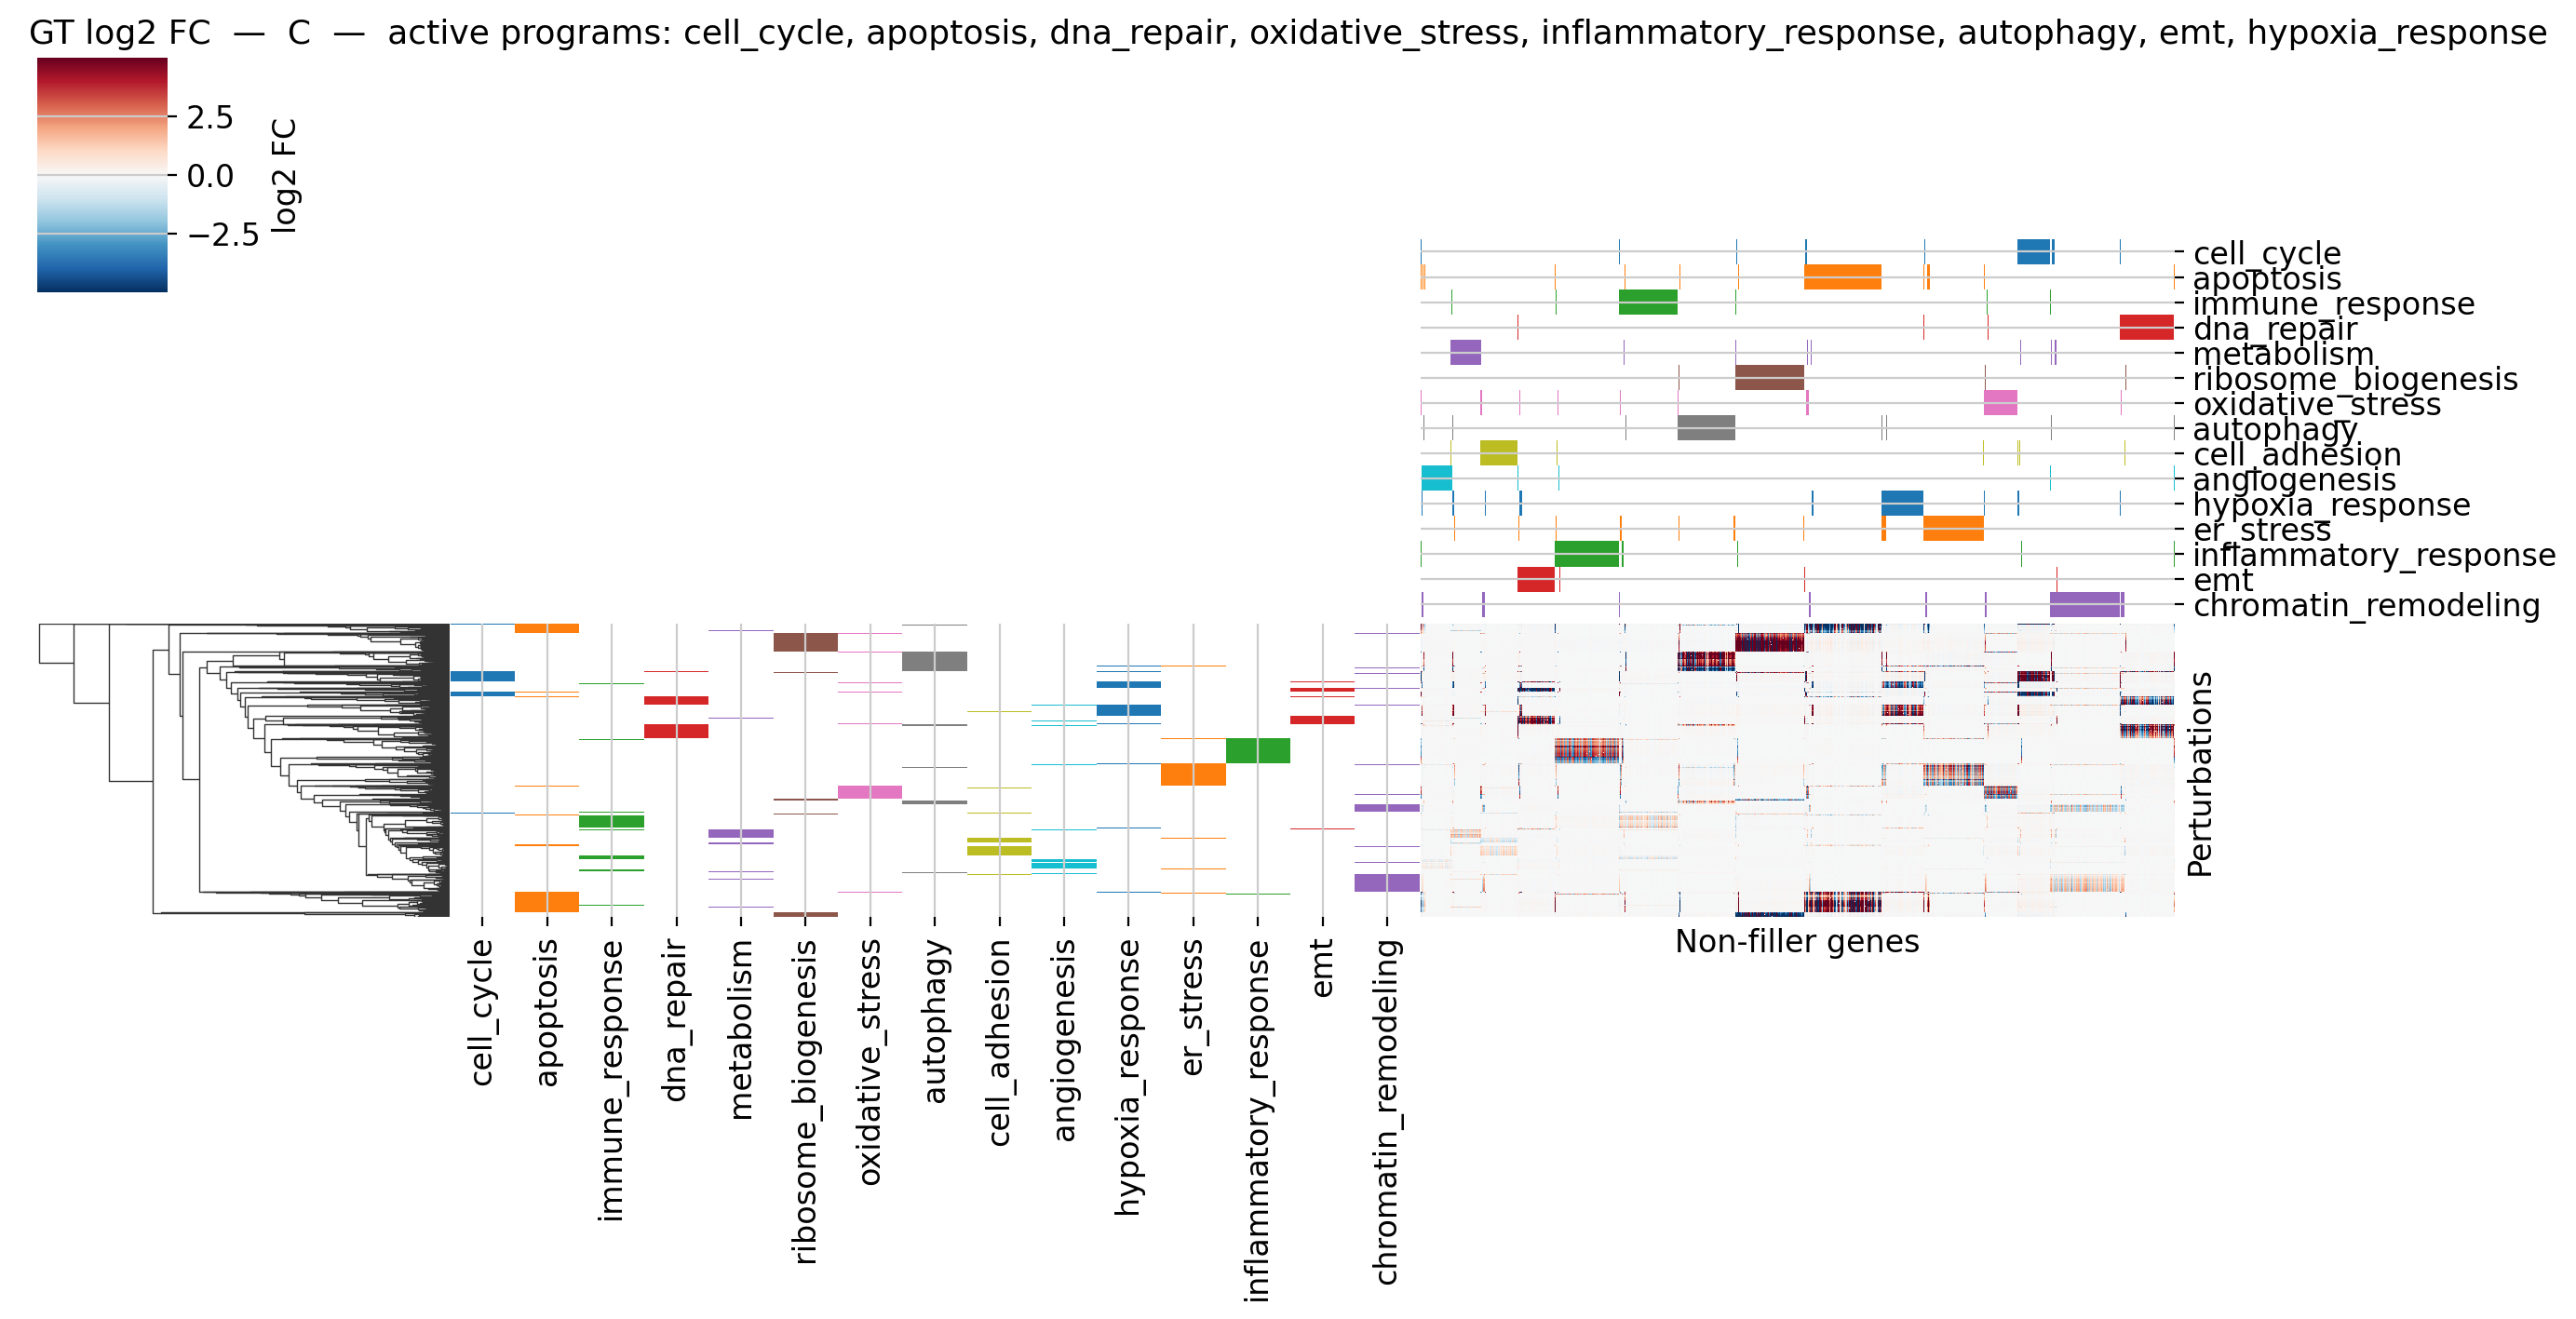

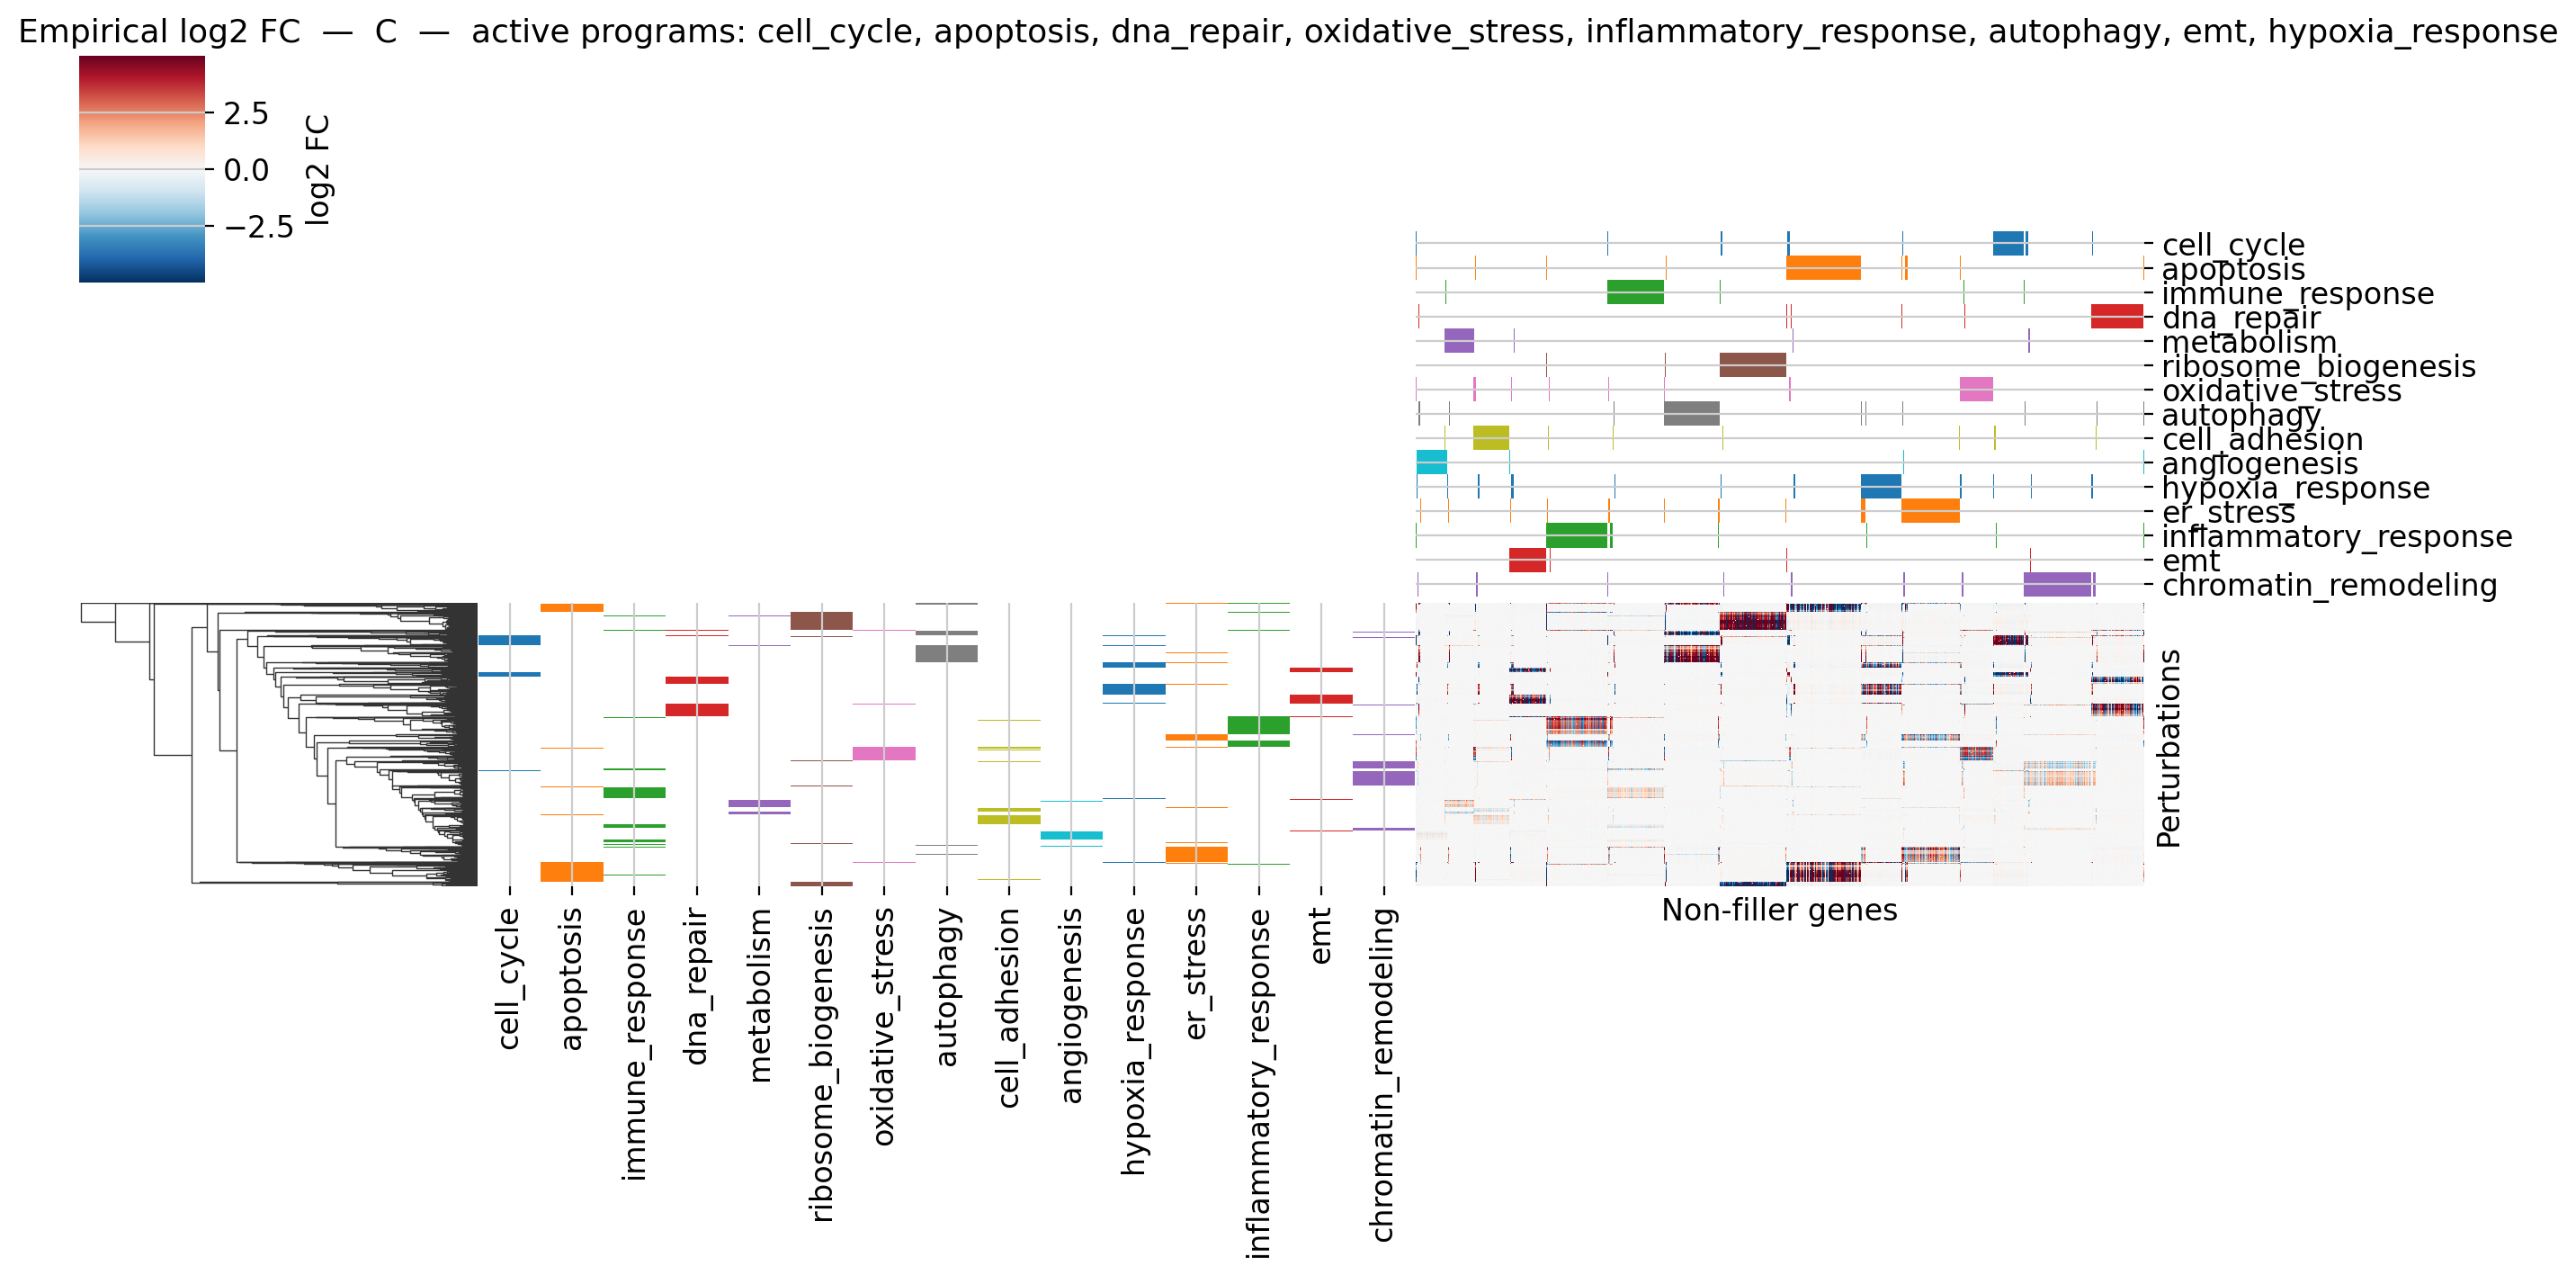

In [7]:
def clustermap_context(fc_df, title, vmax, save=None):
    # Align to non-filler genes in clustered order
    genes = [g for g in clustered_gene_order if g in fc_df.columns]
    fc_aligned = fc_df[genes].replace(-np.inf, np.nan).fillna(0)

    row_colors = build_program_colors(fc_aligned.index)
    col_colors = build_program_colors(genes)

    g = sns.clustermap(
        fc_aligned,
        cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        row_cluster=True, col_cluster=False,
        xticklabels=False, yticklabels=(len(fc_aligned) <= 60),
        row_colors=row_colors, col_colors=col_colors,
        figsize=(14, 7), method='average',
        cbar_kws={'label': 'log2 FC'},
    )
    g.ax_heatmap.set_xlabel('Non-filler genes')
    g.ax_heatmap.set_ylabel('Perturbations')
    g.fig.suptitle(title, fontsize=13, y=1.01)
    plt.show()

# Shared color scale across contexts, for both GT and empirical
all_vals = np.concatenate([
    context_gt[n].replace(-np.inf, np.nan).values.ravel() for n in activities
] + [
    context_emp[n].values.ravel() for n in activities
])
all_vals = all_vals[np.isfinite(all_vals)]
vmax = np.percentile(np.abs(all_vals), 99.5)
print(f"Shared color scale +/-{vmax:.2f}")

for name in activities:
    active_names = [program_names[i] for i in context_active_idx[name]]
    subtitle = f'{name}  —  active programs: {", ".join(active_names)}'
    clustermap_context(context_gt[name], f'GT log2 FC  —  {subtitle}', vmax)
    clustermap_context(context_emp[name], f'Empirical log2 FC  —  {subtitle}', vmax)

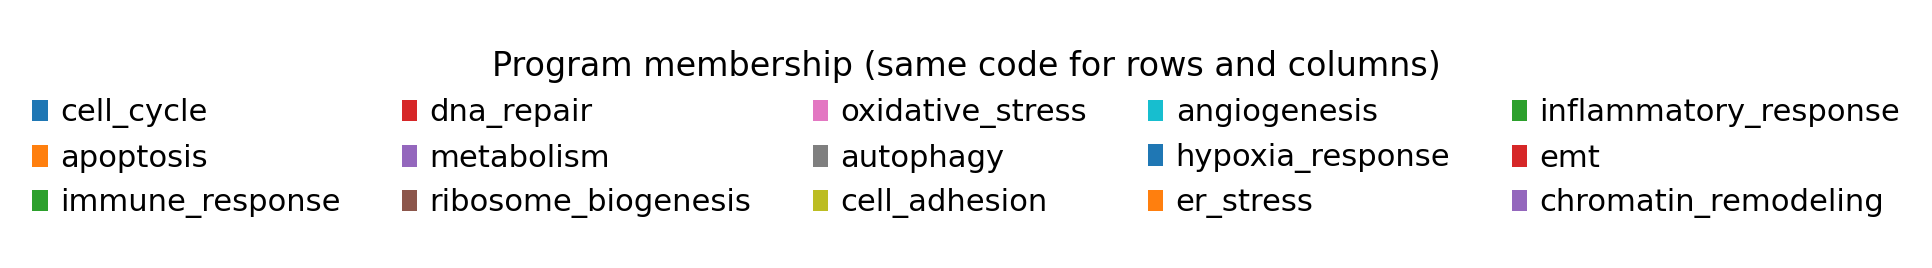

In [8]:
# Legend strip for the program row/column color code
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=p) for p, c in program_colors.items()]
fig_l, ax_l = plt.subplots(figsize=(10, 1.5))
ax_l.axis('off')
ax_l.legend(handles=legend_handles, loc='center', ncol=5,
            title='Program membership (same code for rows and columns)',
            frameon=False)
plt.show()

## Quantitative concordance: GT vs empirical log2 FC

The heatmaps above show GT and empirical log2 FC side-by-side per context.
Here we quantify how well `empirical_log2fc()` (mean log2(X+1) difference)
recovers the simulator's ground-truth log2 FC.

We expect Pearson `r` < 1 because the empirical estimator on negative-binomial
counts attenuates signal (especially for genes with low control expression),
so a calibration slope < 1 (shrinkage) is normal.


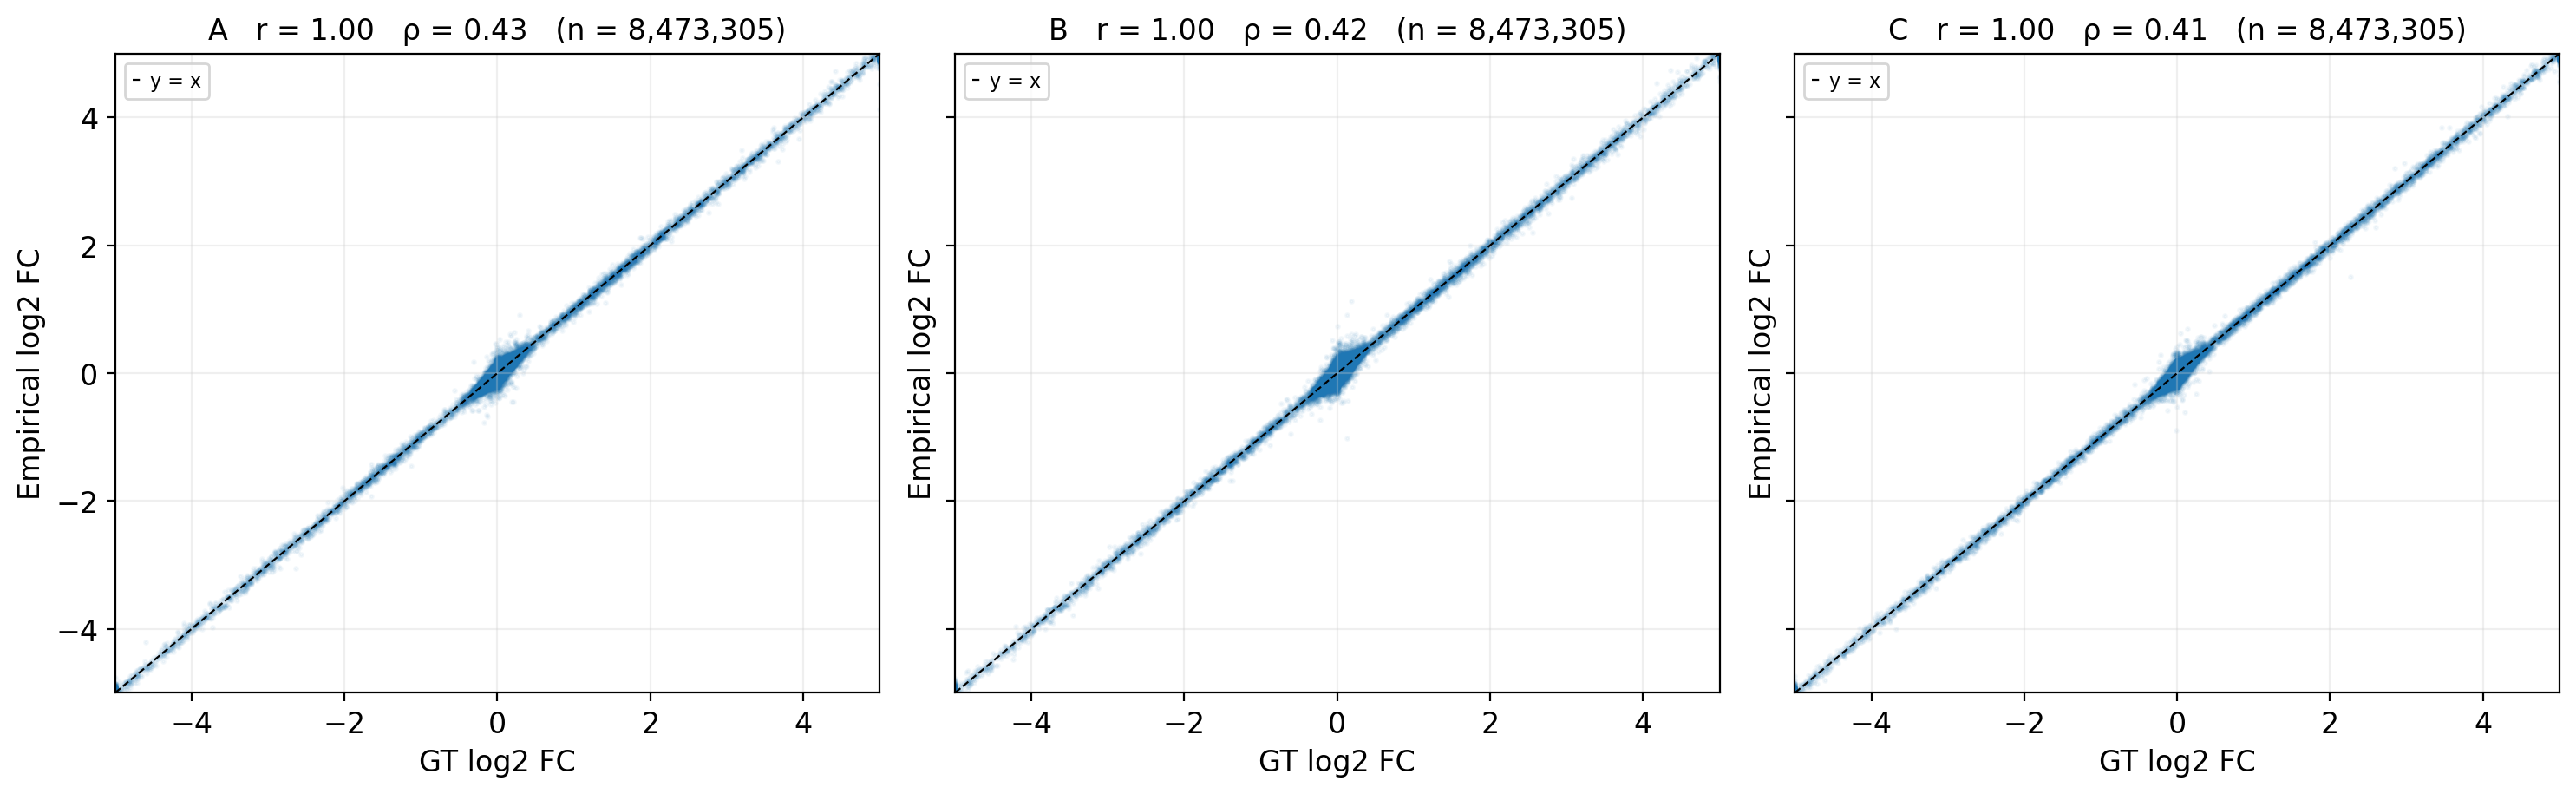

In [9]:
from scipy.stats import pearsonr, spearmanr

def aligned_pair(gt_df, emp_df):
    """Intersect on (perturbation, gene) and return matched flat arrays + axes."""
    perts = sorted(set(gt_df.index)   & set(emp_df.index))
    genes = sorted(set(gt_df.columns) & set(emp_df.columns))
    g = gt_df.loc[perts, genes].values
    e = emp_df.loc[perts, genes].values
    mask = np.isfinite(g) & np.isfinite(e)
    return g[mask], e[mask], perts, genes

# Per-context scatter of GT vs empirical
fig, axes = plt.subplots(1, len(activities), figsize=(5*len(activities), 4.7),
                          sharex=True, sharey=True)
for ax, name in zip(axes, activities):
    g, e, _, _ = aligned_pair(context_gt[name], context_emp[name])
    r, _   = pearsonr(g, e)
    rho, _ = spearmanr(g, e)
    if g.size > 200_000:
        idx = np.random.default_rng(0).choice(g.size, 200_000, replace=False)
        gs, es = g[idx], e[idx]
    else:
        gs, es = g, e
    ax.scatter(gs, es, s=2, alpha=0.05, rasterized=True)
    lim = max(np.percentile(np.abs(g), 99.5), np.percentile(np.abs(e), 99.5))
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='y = x')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('GT log2 FC'); ax.set_ylabel('Empirical log2 FC')
    ax.set_title(f'{name}   r = {r:.2f}   ρ = {rho:.2f}   (n = {g.size:,})')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


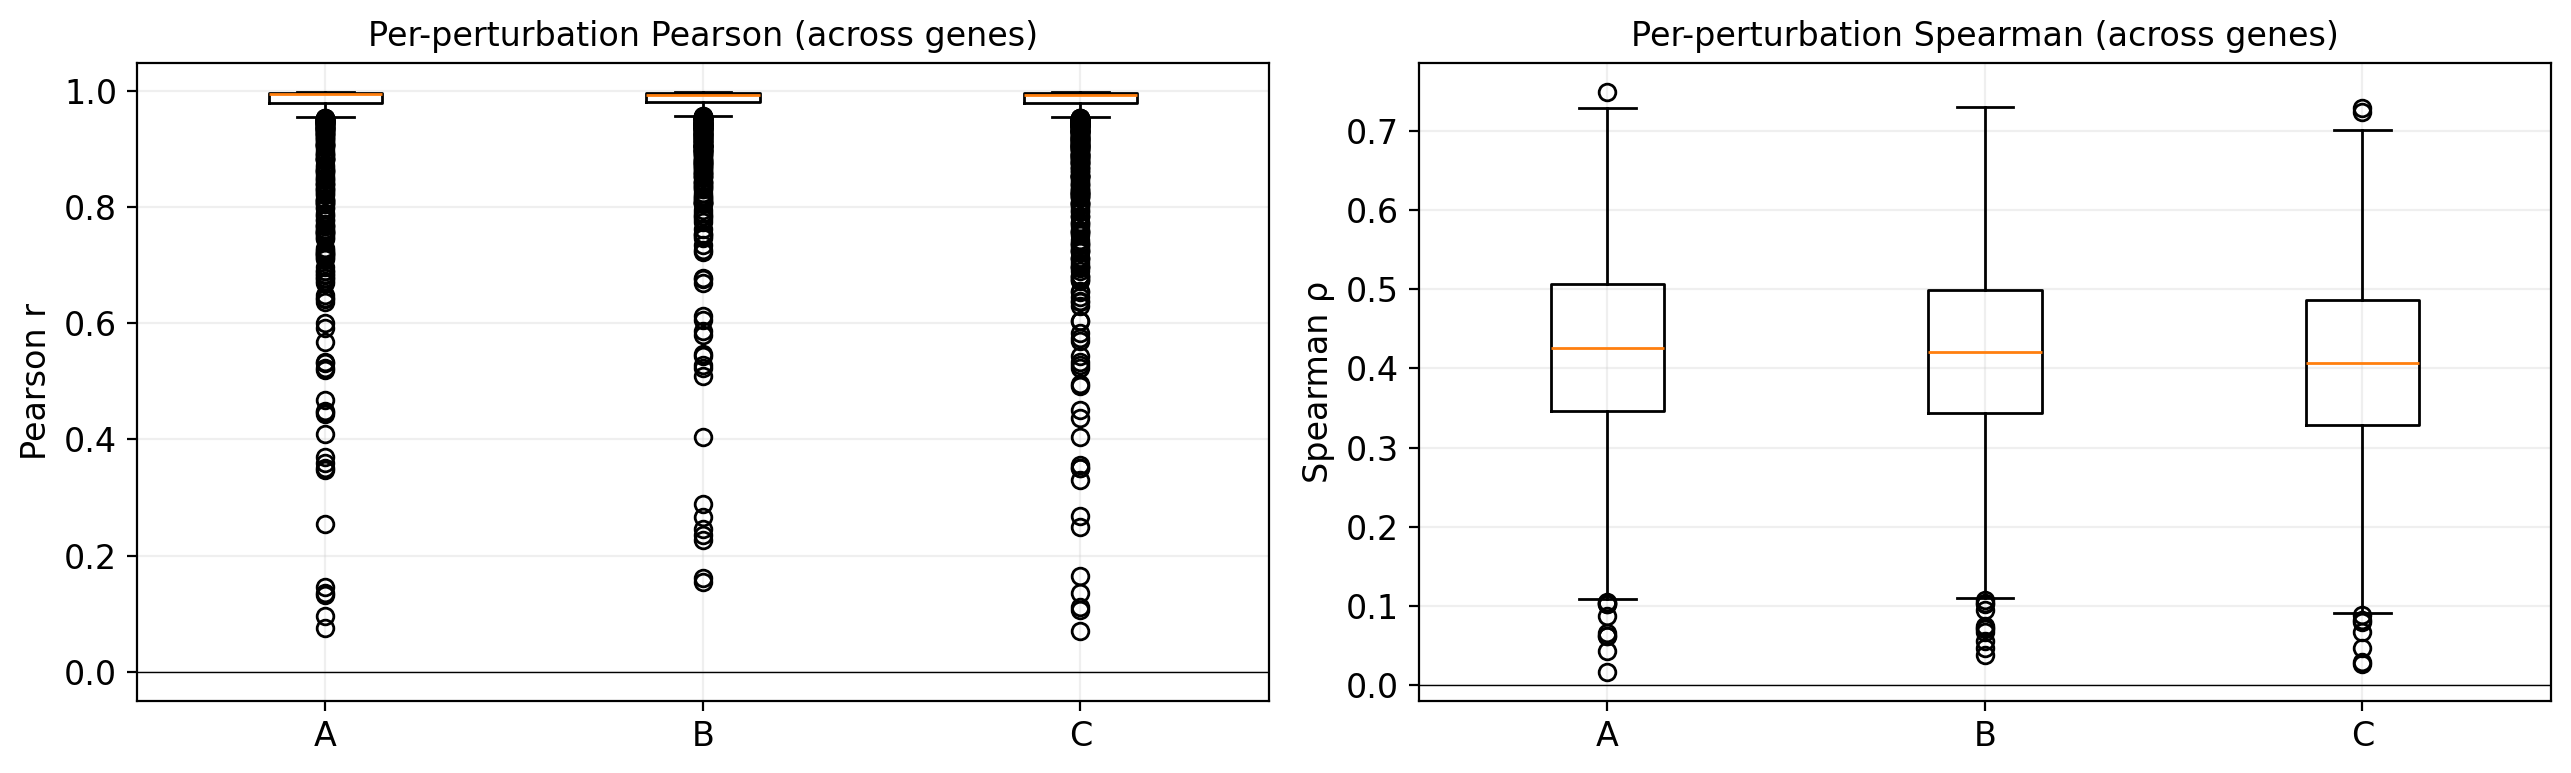

A:  median r = 0.995,  median ρ = 0.426,  mean RMSE = 0.054   (n_perts = 1695)
B:  median r = 0.993,  median ρ = 0.420,  mean RMSE = 0.056   (n_perts = 1695)
C:  median r = 0.994,  median ρ = 0.406,  mean RMSE = 0.054   (n_perts = 1695)


In [10]:
# Per-perturbation Pearson / Spearman across genes, for each context
def per_pert_corr(gt_df, emp_df):
    perts = sorted(set(gt_df.index) & set(emp_df.index))
    genes = sorted(set(gt_df.columns) & set(emp_df.columns))
    rows = []
    for p in perts:
        g = gt_df.loc[p, genes].values
        e = emp_df.loc[p, genes].values
        m = np.isfinite(g) & np.isfinite(e)
        if m.sum() < 5:
            continue
        r, _   = pearsonr(g[m], e[m])
        rho, _ = spearmanr(g[m], e[m])
        rows.append({
            'perturbation': p, 'pearson': r, 'spearman': rho,
            'rmse':       float(np.sqrt(np.mean((g[m] - e[m])**2))),
            'gt_l2_norm': float(np.linalg.norm(g[m])),
        })
    return pd.DataFrame(rows)

per_pert = {name: per_pert_corr(context_gt[name], context_emp[name]) for name in activities}

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].boxplot([per_pert[n]['pearson']  for n in activities], labels=list(activities))
ax[0].set_ylabel('Pearson r'); ax[0].set_title('Per-perturbation Pearson (across genes)')
ax[1].boxplot([per_pert[n]['spearman'] for n in activities], labels=list(activities))
ax[1].set_ylabel('Spearman ρ'); ax[1].set_title('Per-perturbation Spearman (across genes)')
for a in ax:
    a.axhline(0, color='k', lw=0.5); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for name in activities:
    pp = per_pert[name]
    print(f'{name}:  median r = {pp.pearson.median():.3f},  '
          f'median ρ = {pp.spearman.median():.3f},  '
          f'mean RMSE = {pp.rmse.mean():.3f}   '
          f'(n_perts = {len(pp)})')


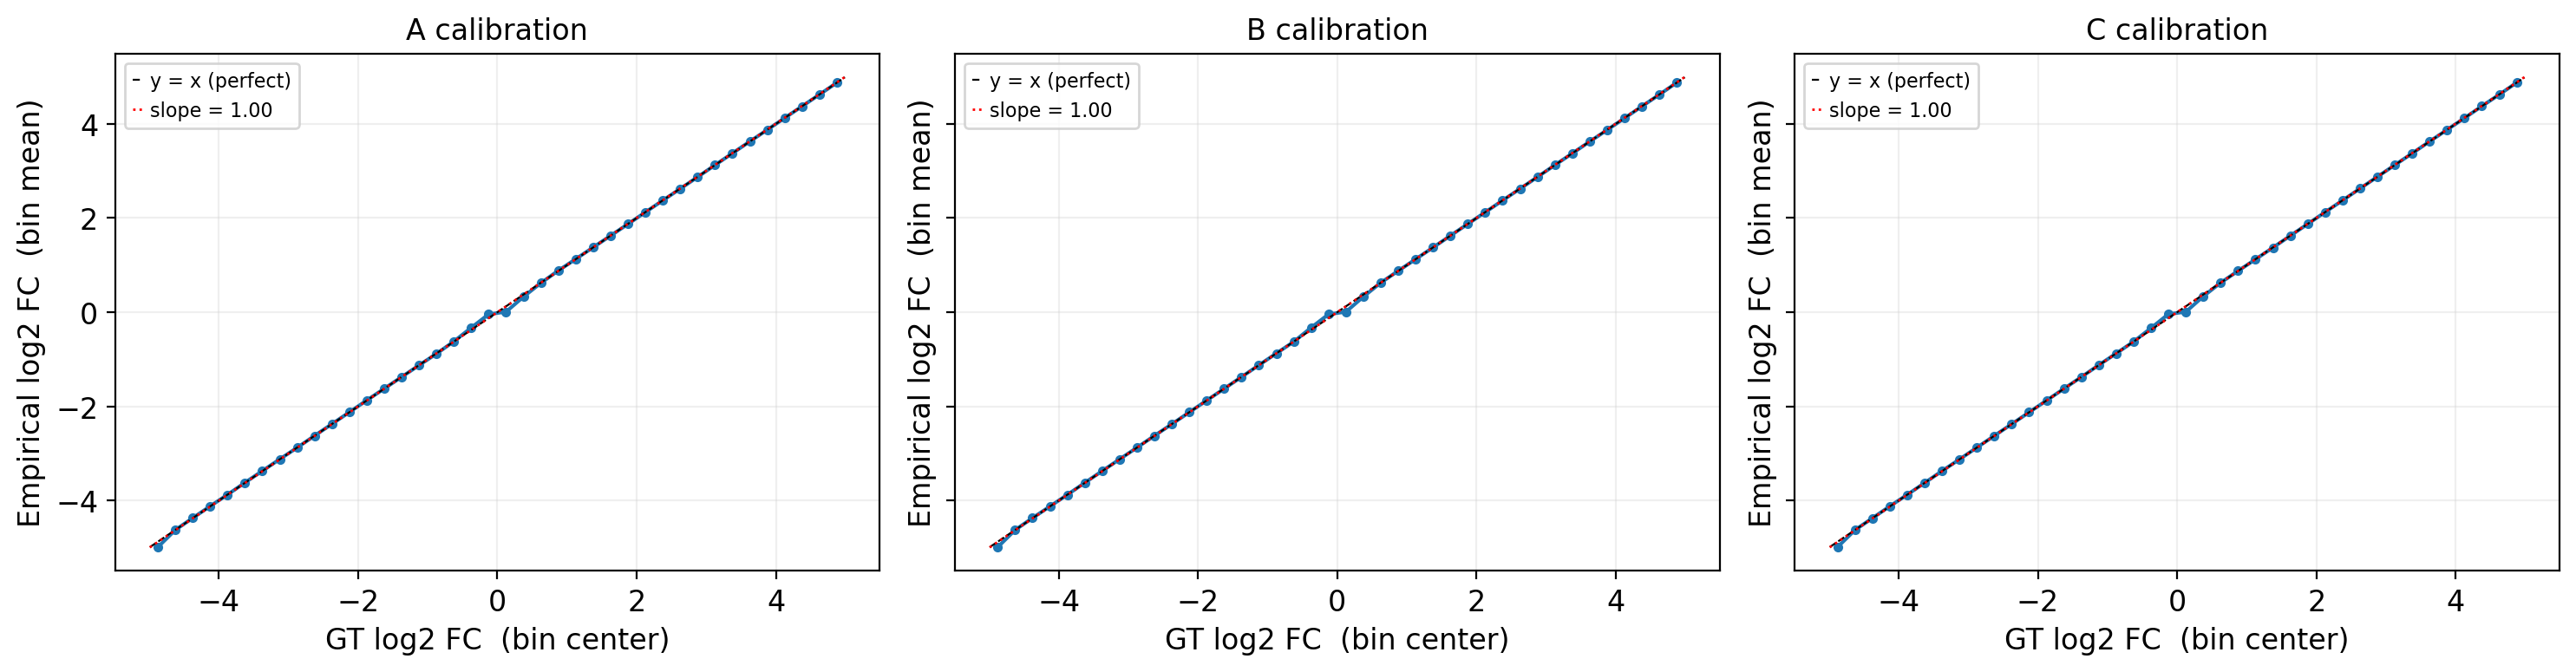

In [11]:
# Calibration: bin by GT magnitude, plot bin-mean empirical against bin-mean GT.
# Slope < 1 indicates the empirical estimator shrinks effect sizes vs ground truth.
fig, axes = plt.subplots(1, len(activities), figsize=(5*len(activities), 4),
                          sharex=True, sharey=True)
for ax, name in zip(axes, activities):
    g, e, _, _ = aligned_pair(context_gt[name], context_emp[name])
    # 40 bins, ignore bins with <5 samples
    bins = np.linspace(g.min(), g.max(), 41)
    idx  = np.digitize(g, bins)
    centers, mean_emp = [], []
    for i in range(1, len(bins)):
        sel = (idx == i)
        if sel.sum() >= 5:
            centers.append(0.5 * (bins[i-1] + bins[i]))
            mean_emp.append(e[sel].mean())
    centers, mean_emp = np.array(centers), np.array(mean_emp)
    ax.plot(centers, mean_emp, '-o', ms=3)
    lim = max(np.abs(centers).max(), np.abs(mean_emp).max())
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='y = x (perfect)')
    # OLS slope of mean_emp ~ centers (forced through 0)
    slope = (centers * mean_emp).sum() / (centers**2).sum()
    ax.plot([-lim, lim], [-lim*slope, lim*slope], 'r:', lw=1, label=f'slope = {slope:.2f}')
    ax.set_xlabel('GT log2 FC  (bin center)')
    ax.set_ylabel('Empirical log2 FC  (bin mean)')
    ax.set_title(f'{name} calibration')
    ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


In [12]:
# Summary table: global metrics + signal-restricted metrics (|GT| > 0.1)
rows = []
for name in activities:
    g, e, _, _ = aligned_pair(context_gt[name], context_emp[name])
    r_all,   _ = pearsonr(g, e)
    rho_all, _ = spearmanr(g, e)
    mask = np.abs(g) > 0.1
    if mask.sum() > 10:
        r_sig, _ = pearsonr(g[mask], e[mask])
        sign_agree = (np.sign(g[mask]) == np.sign(e[mask])).mean()
    else:
        r_sig, sign_agree = np.nan, np.nan
    slope = (g * e).sum() / (g**2).sum()  # OLS through 0:  emp ≈ slope · GT
    rows.append({
        'context':                name,
        'n_entries':              int(g.size),
        'pearson_all':            r_all,
        'spearman_all':           rho_all,
        'rmse':                   float(np.sqrt(np.mean((g - e)**2))),
        'mae':                    float(np.mean(np.abs(g - e))),
        'slope_emp_vs_gt':        float(slope),
        'frac_|GT|>0.1':          float(mask.mean()),
        'pearson_|GT|>0.1':       r_sig,
        'sign_agreement_|GT|>0.1': sign_agree,
    })
summary_df = pd.DataFrame(rows)
print(summary_df.round(3).to_string(index=False))


context  n_entries  pearson_all  spearman_all  rmse   mae  slope_emp_vs_gt  frac_|GT|>0.1  pearson_|GT|>0.1  sign_agreement_|GT|>0.1
      A    8473305        0.996         0.431 0.054 0.042              1.0          0.070             1.000                    0.991
      B    8473305        0.995         0.423 0.056 0.044              1.0          0.072             0.999                    0.987
      C    8473305        0.995         0.412 0.054 0.042              1.0          0.063             1.000                    0.991
